In [122]:
%matplotlib inline
from pylab import *
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

import warnings

warnings.filterwarnings('ignore')

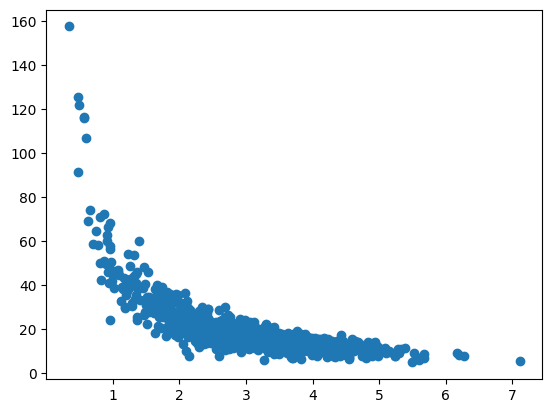

In [123]:
np.random.seed(2)
pageSpeeds = np.random.normal (3.0,1.0,1000)
purchaseAmount = np.random.normal (50.0, 10.0, 1000) / pageSpeeds
scatter(pageSpeeds,purchaseAmount)

In [124]:

np.random.seed(42)
x = np.linspace(0,10,30).reshape(-1,1)

y_true = 5+6*x.flatten()-0.5*(x.flatten()**2)

noise = np.random.normal(0,2, size=x.shape[0])

y = y_true + noise

In [125]:
y

array([ 5.99342831,  6.73298388, 10.19549598, 13.71787898, 11.85630681,
       13.39022787, 18.43190958, 18.10442951, 16.80778131, 19.89011414,
       18.81751658, 19.6333443 , 21.75027413, 18.02242881, 18.86288728,
       21.53297548, 20.85780982, 23.61898218, 21.16254876, 20.02319284,
       25.52939504, 21.7779361 , 21.87703025, 18.28605654, 19.32146047,
       19.78783805, 16.30086659, 18.2722046 , 15.11857993, 14.4166125 ])

Linear Regression

In [126]:
lr = LinearRegression()
lr.fit(x,y)

y_linear_pred =lr.predict(x) 

Polynomial Regression


In [127]:
degree = 1

poly_reg = make_pipeline(
    PolynomialFeatures(degree),
    LinearRegression()
)

poly_reg.fit(x,y)
y_poly_pred = poly_reg.predict(x)

In [128]:
X_smooth = np.linspace(0,10,200).reshape(-1,1)
y_smooth_poly = poly_reg.predict(X_smooth)
y_smooth_linear =lr.predict(X_smooth)


In [129]:
linear_r2 = r2_score(y,y_linear_pred)
poly_r2 = r2_score(y,y_poly_pred)

print('Linear Regression R2:', round(linear_r2,2))
print('Polynomial Regression R2:', round(poly_r2, 2))


Linear Regression R2: 0.28
Polynomial Regression R2: 0.28


In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.7, label='Data points')
plt.plot(X_smooth, y_smooth_linear, color='red', label='Linear Regression')
plt.plot(X_smooth, y_smooth_poly, color='green', label='Polynomial Regression')
plt.xlabel('Study Hours')
plt.ylabel('Polynomial regression formulas')
plt.legend()
plt.grid()
savefig('Polynomial regression.png',dpi=1080)
plt.show()